# Fundamental Programming for Geospatial Data Analysis
## Machine Learning
### Introduction to exploratory spatial data analysis

#### M. Khodadadzadeh
*version: Oct 2025*

## Introduction

The document helps you to practice some spatial data analysis tasks. Data were downloaded from GeoDa Data and Lab: https://geodacenter.github.io/data-and-lab//. The full dataset and its attributes can be explored here: https://geodacenter.github.io/data-and-lab/nepal/. Please note that the dataset has been processed and only a small number of variables are included in this practical.

## Exercise 1

In the previous practicals you learned how to load tabular datasets using Pandas. GeoPandas is an open source library that makes working with geospatial data in python easier. A GeoDataFrame is a tabular data structure that contains a GeoSeries. A GeoSeries is essentially a vector where each entry in the vector is a set of shapes corresponding to one observation. Geopandas has three basic classes of geometric objects:

- Points / Multi-Points

- Lines / Multi-Lines

- Polygons / Multi-Polygons

Geopandas can read almost any vector-based spatial data format including ESRI shapefile, GeoJSON files and more using the command: geopandas.read_file()

You can find a comprehensive documentation here: https://geopandas.org/en/stable/docs.html

Now let's read the Nepal dataset (that contains development-related data for 75 districts in Nepal) and map the "Deprivation in economic provisioning" variable.

In [1]:
# Reading the Nepal Dataset using geopandas
import geopandas as gpd
gdf = gpd.read_file("nepal_dev.shp")
gdf.head()

,id,district,depecprov,povindex,pcinc,malkids,nosafh20,schlpkid,ad_illit,depr_class,geometry
0,0,Baglung,27.01,27.33,354,42.9,11.12,9.1924,34.46,1,"POLYGON ((83.10834 28.62020, 83.10560 28.60976..."
1,1,Mustang,31.51,31.16,1189,54.7,8.32,44.0252,38.65,1,"POLYGON ((83.99726 29.31675, 84.00000 29.31576..."
2,2,Myagdi,30.03,28.54,636,47.5,12.56,15.1096,34.84,1,"POLYGON ((83.50688 28.79306, 83.51024 28.78809..."
3,3,Parbat,21.84,24.62,627,26.2,17.47,16.4131,32.43,0,"POLYGON ((83.70261 28.39837, 83.70435 28.39452..."
4,4,Bhaktapur,22.58,19.43,854,26.9,18.25,11.1621,21.87,0,"POLYGON ((85.52173 27.71822, 85.52359 27.71375..."


First, let's check if there is a missing (null) value in this variable. Within pandas and geopandas, a missing value is denoted by NaN. At the base level, they offer two functions to test for missing data, isnull() and notnull().

In [2]:
print(gdf['depecprov'].isnull().sum())
print(gdf['depecprov'].notnull().sum())

0
75


As you see we have zero NaN values and thus we have a value for each of the 75 districts. If we had NaN values we should have replaced them. A straightforward solution is to fill the NaN values with the mean:
gdf['Name of the variable'].fillna((gdf['Name of the variable'].mean()), inplace=True)

Now let's map!

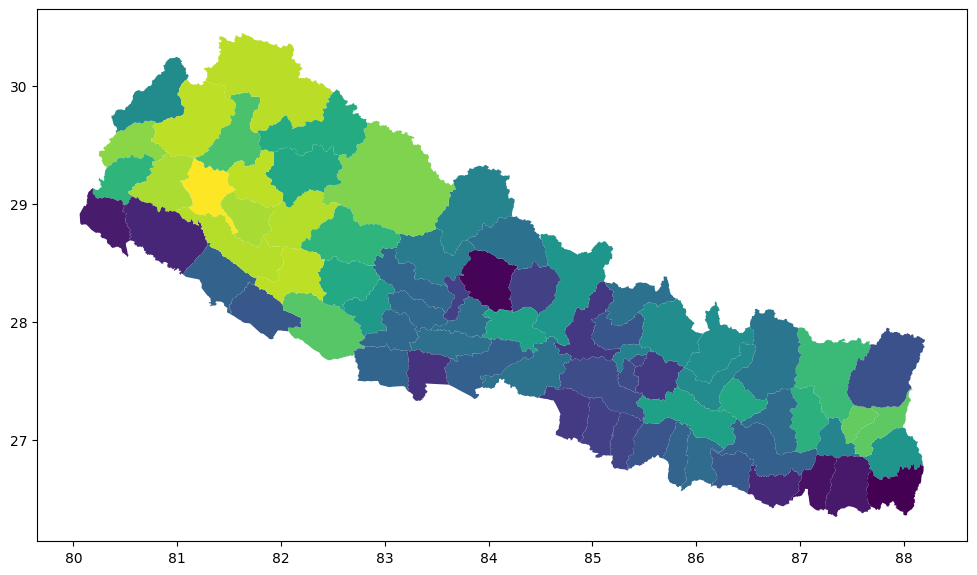

In [3]:
import matplotlib.pyplot as plt
gdf.plot(column='depecprov')
plt.gcf().set_size_inches(12,10)

# # or 
# fig, ax = plt.subplots(figsize=(12,10))
# gdf.plot(column='depecprov', ax=ax)

We can also map the quantiles of this variable:

<AxesSubplot: >

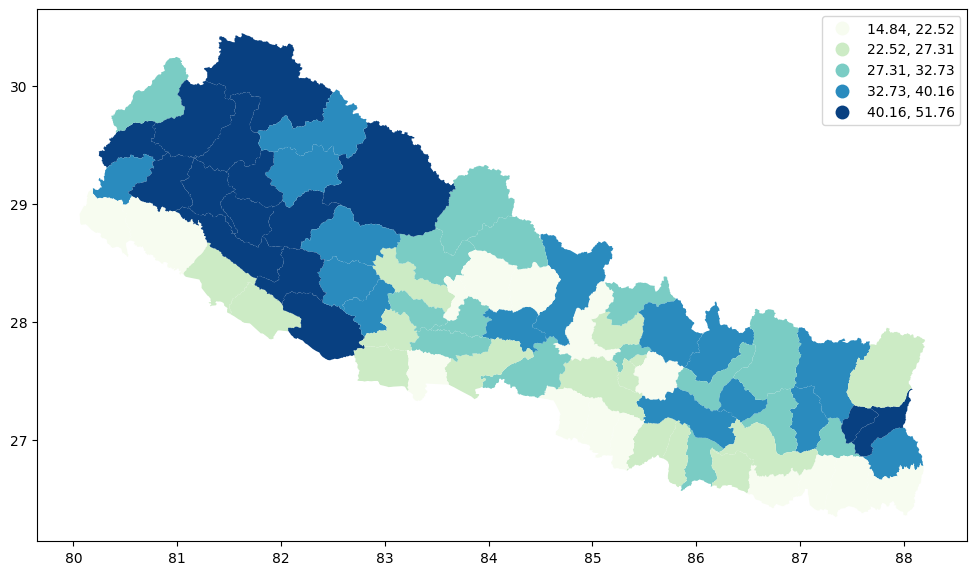

In [4]:
fig, ax = plt.subplots(figsize=(12,10))
gdf.plot(column='depecprov', scheme='Quantiles', k=5, cmap='GnBu', legend=True, ax=ax)

## Exercise 2

The Spatial weight between neighborhoods indicates geographical similarity. For this purpose we will use a Python Spatial Analysis Library called libpysal: https://pysal.org/libpysal/

In [5]:
import libpysal as lps

wq =  lps.weights.Queen.from_dataframe(gdf)
wq.transform = 'r'
lag_depecprov = lps.weights.lag_spatial(wq, gdf['depecprov'])
lag_depecprov

array([31.64666667, 34.40666667, 29.66      , 25.554     , 25.16      ,
       28.45166667, 24.12428571, 28.78285714, 24.51      , 28.3375    ,
       26.16333333, 28.48166667, 28.38      , 31.57333333, 29.33666667,
       31.57333333, 28.26333333, 26.76333333, 22.17333333, 25.12222222,
       24.66      , 26.3425    , 26.89166667, 30.926     , 31.95142857,
       27.92      , 33.254     , 23.4       , 34.5275    , 24.92      ,
       25.67      , 29.952     , 41.79666667, 32.72      , 30.288     ,
       22.50333333, 24.15333333, 34.75833333, 28.73111111, 41.645     ,
       32.165     , 46.715     , 28.83      , 46.134     , 42.81      ,
       46.69833333, 41.65714286, 35.478     , 38.84      , 34.825     ,
       48.745     , 44.44714286, 40.92857143, 37.07666667, 42.22      ,
       44.4275    , 43.64333333, 43.75      , 33.12833333, 32.156     ,
       38.13      , 39.095     , 37.77142857, 27.252     , 27.75833333,
       28.51      , 26.586     , 25.774     , 26.12142857, 29.78

Now let's calculate the Global spatial autocorrelation with Morans' I

In [6]:
from esda.moran import Moran
mi = Moran(gdf['depecprov'], wq, two_tailed=False)
help(mi)

Help on Moran in module esda.moran object:

class Moran(builtins.object)
 |  Moran(y, w, transformation='r', permutations=999, two_tailed=True)
 |  
 |  Moran's I Global Autocorrelation Statistic
 |  
 |  Parameters
 |  ----------
 |  
 |  y               : array
 |                    variable measured across n spatial units
 |  w               : W
 |                    spatial weights instance
 |  transformation  : string
 |                    weights transformation,  default is row-standardized "r".
 |                    Other options include "B": binary,  "D":
 |                    doubly-standardized,  "U": untransformed
 |                    (general weights), "V": variance-stabilizing.
 |  permutations    : int
 |                    number of random permutations for calculation of
 |                    pseudo-p_values
 |  two_tailed      : boolean
 |                    If True (default) analytical p-values for Moran are two
 |                    tailed, otherwise if False, they a

In [7]:
print(mi.I)

0.5078048238407304


What can you say about the data based on the Moran's Index?